# DAQC and DAQC+CD for MaxCut

This notebook presents a documented implementation of the digital-analog quantum computation (DAQC) algorithm and its counterdiabatic (CD) extension for the MaxCut problem.

## MaxCut, Ising cost Hamiltonian, and DAQC schedule

In the DAQC construction used here, the time-dependent Hamiltonian is written as

$$
H(t) = (1-\lambda(t)) H_0 + \lambda(t) H_p,
$$

with

$$
H_0 = \sum_i Z_i, \qquad H_p = \sum_{i<j} J_{ij} X_i X_j, \qquad \lambda(t)=\frac{t}{T}.
$$

The evolution is discretized into steps of size $\Delta t$, and each layer is approximated by alternating analog MS-type interaction blocks and local phase blocks.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from utils import (
    benchmark_success_probability,
    build_daqc_circuit,
    build_lambda_schedule,
    build_noise_model,
    calc_alpha_1,
    circuit_style,
    counts_to_probabilities,
    run_counts,
    solve_maxcut_from_matrix,
    weights_to_edges,
)


## Problem instance

We encode the graph by an upper-triangular weight matrix $J$. For exact classical comparison, we also convert $J$ into a native edge list representation.

In [2]:
J = [
    [0.0, 1.0, 1.0, 1.0],
    [0.0, 0.0, 1.0, 1.0],
    [0.0, 0.0, 0.0, 1.0],
    [0.0, 0.0, 0.0, 0.0],
]

n = len(J)
edges = weights_to_edges(J)
edges


[(0, 1, 1.0), (0, 2, 1.0), (0, 3, 1.0), (1, 2, 1.0), (1, 3, 1.0), (2, 3, 1.0)]

## Exact classical solution

The helper `solve_maxcut_from_matrix` computes the exact MaxCut value, all optimal bitstrings, and the corresponding ground-state energy of $H_C$.

In [3]:
exact = solve_maxcut_from_matrix(J)
solutions_str = exact['solutions']

print('Edges:', exact['edges'])
print('Exact MaxCut value:', exact['best_cut'])
print('Optimal bitstrings:', solutions_str)
print('Ground-state energy:', exact['ground_energy'])


Edges: [(0, 1, 1.0), (0, 2, 1.0), (0, 3, 1.0), (1, 2, 1.0), (1, 3, 1.0), (2, 3, 1.0)]
Exact MaxCut value: 4.0
Optimal bitstrings: ['0011', '0101', '0110', '1001', '1010', '1100']
Ground-state energy: -4.0


## Counterdiabatic term

The CD coefficient used in the original notebook is

$$
\alpha_1(\lambda) = -\frac{1}{4}\,\frac{\sum_{i<j} J_{ij}^2}{4(1-\lambda)^2\sum_{i<j} J_{ij}^2 + \lambda^2\left(\sum_{i<j} J_{ij}^4 + 6\sum_{i<j<k} (J_{ij}^2 J_{ik}^2 + J_{ij}^2 J_{jk}^2 + J_{ik}^2 J_{jk}^2)\right)}.
$$

The CD block is decomposed into sparse row-based and column-based MS blocks, surrounded by $S$ and $S^\dagger$ gates (see circuits produced in `figures.ipynb`).


In [4]:
T = 4.0
dt = 1.0
N = 1
lambda_schedule = build_lambda_schedule(T, dt)
alpha_values = [calc_alpha_1(lam, J) for lam in lambda_schedule]

for lam, alpha in zip(lambda_schedule, alpha_values):
    print(f'lambda={lam:.2f}, alpha_1={alpha:.6f}')


lambda=0.00, alpha_1=-0.062500
lambda=0.25, alpha_1=-0.081633
lambda=0.50, alpha_1=-0.058824
lambda=0.75, alpha_1=-0.033058
lambda=1.00, alpha_1=-0.019231


## Build DAQC circuits

The first circuit implements the baseline DAQC evolution. The second circuit adds the CD correction in each Trotter layer.

In [6]:
qc_daqc = build_daqc_circuit(J, T=T, dt=dt, N=N, with_cd=False, measure=True)
qc_daqc_cd = build_daqc_circuit(J, T=T, dt=dt, N=N, with_cd=True, measure=True)


## Noisy simulation

We use a simple depolarizing noise model applied only to the MS-type analog blocks.

In [7]:
shots = 2000
p_ms = 1e-6
noise_model = build_noise_model(p_ms=p_ms, n=n)

counts_daqc = run_counts(qc_daqc, noise_model=noise_model, shots=shots)
counts_daqc_cd = run_counts(qc_daqc_cd, noise_model=noise_model, shots=shots)

print('DAQC counts:', counts_daqc)
print('DAQC+CD counts:', counts_daqc_cd)


DAQC counts: {'0111': 66, '1000': 43, '1110': 63, '1011': 60, '1001': 158, '0101': 157, '1010': 170, '0100': 62, '1100': 142, '1101': 57, '1111': 303, '0001': 65, '0011': 167, '0000': 315, '0010': 54, '0110': 118}
DAQC+CD counts: {'1110': 18, '0111': 23, '0010': 22, '0100': 29, '1100': 230, '1111': 235, '1101': 36, '1000': 19, '1011': 25, '1010': 195, '0001': 35, '0011': 247, '0110': 214, '0101': 209, '0000': 259, '1001': 204}


## State distribution and comparison with the exact solution

We convert counts to probabilities and color the exact classical MaxCut solutions in green. All other measured states are shown in red.

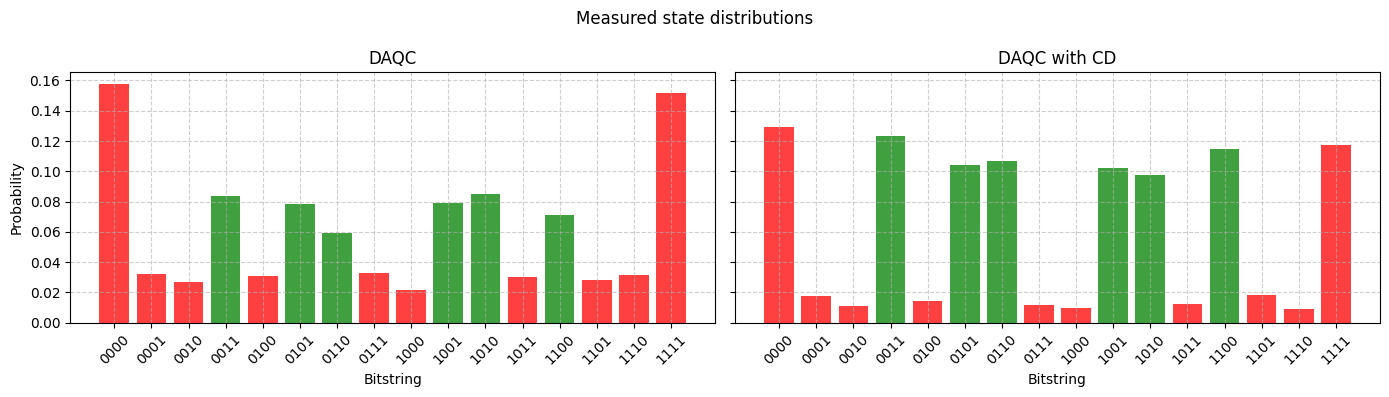

In [12]:
prob_daqc = counts_to_probabilities(counts_daqc, shots=shots)
prob_daqc_cd = counts_to_probabilities(counts_daqc_cd, shots=shots)
labels = sorted(set(prob_daqc) | set(prob_daqc_cd))

values_daqc = [prob_daqc.get(label, 0.0) for label in labels]
values_daqc_cd = [prob_daqc_cd.get(label, 0.0) for label in labels]
colors = ['green' if label in solutions_str else 'red' for label in labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
axes[0].bar(labels, values_daqc, color=colors, alpha=0.75)
axes[0].set_title('DAQC')
axes[0].set_xlabel('Bitstring')
axes[0].set_ylabel('Probability')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(linestyle='--', alpha=0.6)

axes[1].bar(labels, values_daqc_cd, color=colors, alpha=0.75)
axes[1].set_title('DAQC with CD')
axes[1].set_xlabel('Bitstring')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(linestyle='--', alpha=0.6)

plt.suptitle('Measured state distributions')
plt.tight_layout()
plt.show()


## Benchmark over different total times $T$

Finally, we compare the success probability

$$
P_{\mathrm{succ}}(T) = \sum_{z \in \mathcal{S}_{\mathrm{opt}}} p_T(z),
$$

where $\mathcal{S}_{\mathrm{opt}}$ is the set of exact classical MaxCut solutions.


In [9]:
T_values = [1, 2, 3, 4, 5, 6, 7, 8]
benchmark = benchmark_success_probability(
    J,
    T_values=T_values,
    dt=dt,
    N=N,
    p_ms=p_ms,
    shots=shots,
)
benchmark


{'T_values': [1, 2, 3, 4, 5, 6, 7, 8],
 'probabilities': [0.387, 0.3555, 0.5185, 0.425, 0.6065, 0.5, 0.5295, 0.452],
 'probabilities_cd': [0.136,
  0.463,
  0.461,
  0.6515,
  0.647,
  0.599,
  0.5205,
  0.526],
 'solutions': ['0011', '0101', '0110', '1001', '1010', '1100'],
 'best_cut': 4.0,
 'edges': [(0, 1, 1.0),
  (0, 2, 1.0),
  (0, 3, 1.0),
  (1, 2, 1.0),
  (1, 3, 1.0),
  (2, 3, 1.0)]}

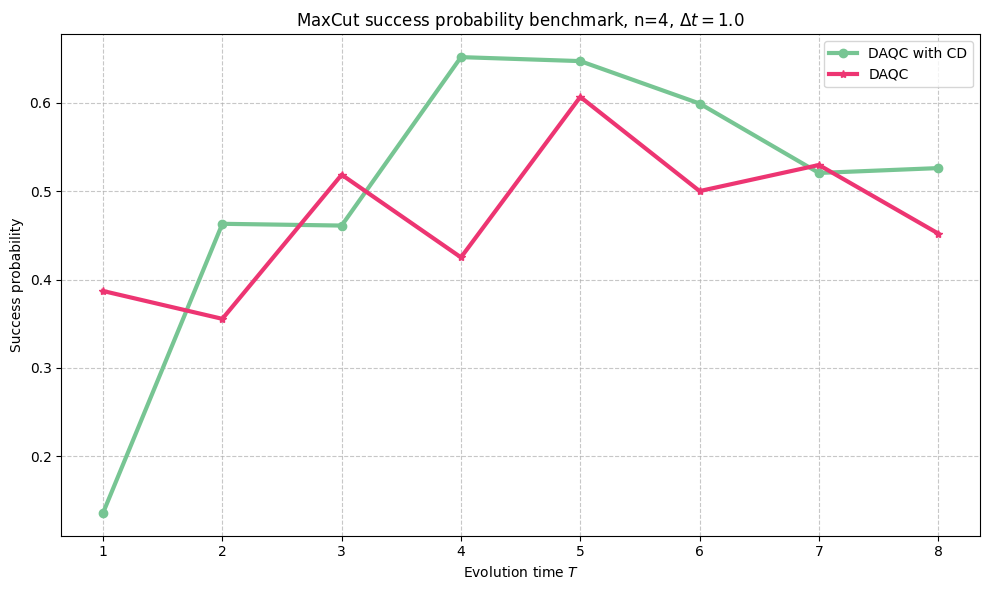

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(benchmark['T_values'], benchmark['probabilities_cd'], marker='o', linewidth=3, label='DAQC with CD', color='#77c593')
plt.plot(benchmark['T_values'], benchmark['probabilities'], marker='*', linewidth=3, label='DAQC', color='#ed3572')
plt.xlabel('Evolution time $T$')
plt.ylabel('Success probability')
plt.title(f'MaxCut success probability benchmark, n={n}, $\\Delta t={dt}$')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()
